In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:
df=pd.read_csv("../data/MSLG_SPA_train.txt",sep="\t")
print(df)

      ID                                               MSLG  \
0    220                         PEZ COLOR AZUL MI FAVORITO   
1    749  YO FELIZ MI HIJO LICENCIA-DE-CONDUCIR ÉL YA TENER   
2    180                 SU LIBRO MATEMÁTICAS USTEDES SACAR   
3    239              YO NECESITAR PAPEL PARA AGUA ABSORBER   
4    673                      dm-ISABEL TENER SU CORONA ORO   
..   ...                                                ...   
485  528                               ALGUIEN ÉL AYUDAR MÍ   
486   37                     MAESTRO ALUMNOS REUNIÓN APARTE   
487  868            AYER CONSTANCIA SECUNDARIA ELLOS DAR MÍ   
488  671                     ESA PERSONA COLMILLO TÚ CUIDAR   
489  301                JUGUETE CARRO YO GUSTAR COLECCIONAR   

                                                   SPA  
0                  Los peces azules son mis favoritos.  
1    Estoy feliz, mi hijo ya tiene licencia de cond...  
2                      Saquen su libro de Matemáticas.  
3              

In [3]:
df.sample(10)

,ID,MSLG,SPA
433,365,JUGUETE MI AHIJADO YO REGALAR ÉL YA,Le regalé un juguete a mi ahijado.
24,143,CHAPULTEPEC YO YA VER ALGUNO DELFÍN,En Chapultepec vi algunos delfines.
387,610,NECESITAR EJERCICIO EJERCICIO PARA SALUD,Es necesario hacer ejercicio para estar sano.
183,822,SU #SEP CALENDARIO AGOSTO TERMINAR,El calendario de la SEP termina en agosto.
201,524,CANTAR+MUJER dm-MADONNA ELLOS ADMIRAR ELLA,Ellos admiran a la cantante Madonna.
299,28,dm-SARA MUCHA ALMEJA ADENTRO MAR ELLA ENCONTRAR,Sara encontró muchas almejas en el mar.
118,43,dm-ROSALÍA TRABAJAR ARCHIVO HOSPITAL,Rosalía trabaja en el archivo del hospital.
365,331,ESE BLANCO GATO RASGUÑAR,Ese gato blanco rasguña.
35,383,MI AMIGO ARGENTINA ANTROPOLOGÍA ELLOS ESTUDIAR YA,Mis amigos argentinos estudiaron antropología.
83,486,OTRO LIBRO YO TENER,Tengo otro libro.


In [4]:
df["len_spa"]=df["SPA"].str.split(" ").apply(len)
df["len_mslg"]=df["MSLG"].str.split(" ").apply(len)
df.head()


,ID,MSLG,SPA,len_spa,len_mslg
0,220,PEZ COLOR AZUL MI FAVORITO,Los peces azules son mis favoritos.,6,5
1,749,YO FELIZ MI HIJO LICENCIA-DE-CONDUCIR ÉL YA TENER,"Estoy feliz, mi hijo ya tiene licencia de cond...",9,8
2,180,SU LIBRO MATEMÁTICAS USTEDES SACAR,Saquen su libro de Matemáticas.,5,5
3,239,YO NECESITAR PAPEL PARA AGUA ABSORBER,Necesito papel para absorber el agua.,6,6
4,673,dm-ISABEL TENER SU CORONA ORO,Isabel tiene una corona de oro.,6,5


In [5]:
df["ratio"] = df["len_spa"] / df["len_mslg"]
df["ratio"].mean()

1.4199029655152104

In [6]:
len_vocmslg=len(set(" ".join(df["MSLG"]).split()))
len_voc_spa=len(set(" ".join(df["SPA"]).split()))
print(len_vocmslg,len_voc_spa)

1079 1420


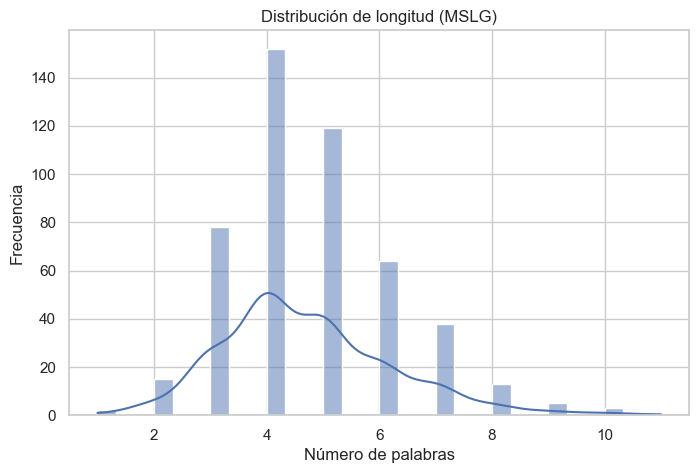

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(8,5))
sns.histplot(df["len_mslg"], bins=30, kde=True)

plt.title("Distribución de longitud (MSLG)")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")

plt.show()

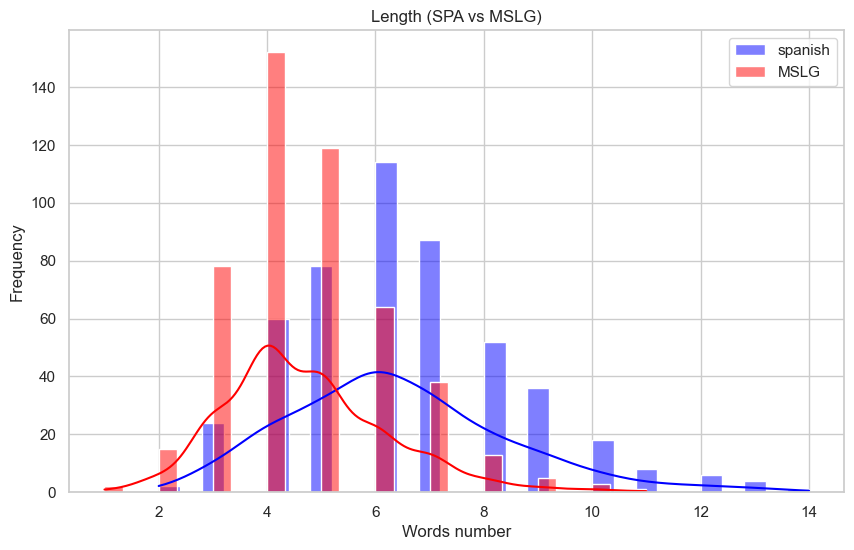

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(df["len_spa"], color="blue", label="spanish", bins=30, kde=True, alpha=0.5)
sns.histplot(df["len_mslg"], color="red", label="MSLG", bins=30, kde=True, alpha=0.5)

plt.legend()
plt.title("Length (SPA vs MSLG)")
plt.xlabel("Words number")
plt.ylabel("Frequency")

plt.show()

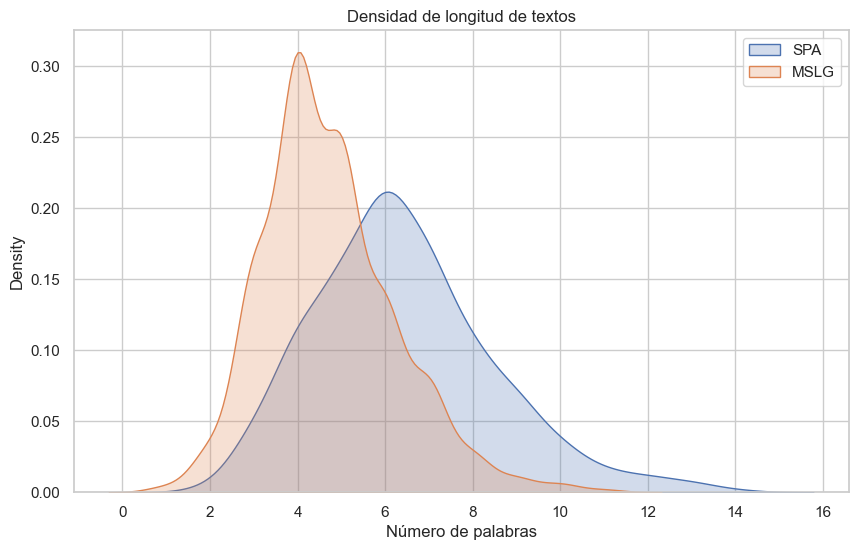

In [13]:
plt.figure(figsize=(10,6))

sns.kdeplot(df["len_spa"], label="SPA", fill=True)
sns.kdeplot(df["len_mslg"], label="MSLG", fill=True)

plt.legend()
plt.title("Densidad de longitud de textos")
plt.xlabel("Número de palabras")

plt.show()

<Axes: >

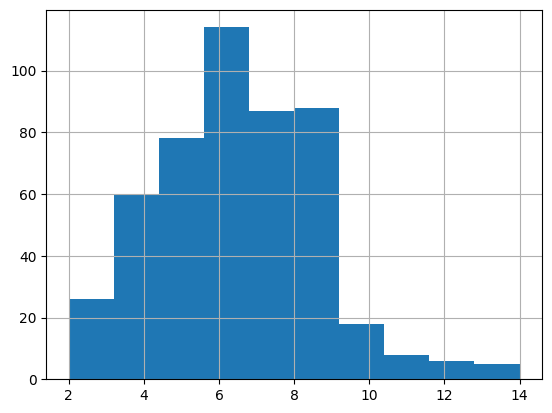

In [8]:
df["len_spa"].hist()

In [9]:
from collections import Counter

mslg_tokens=Counter(" ".join(df["MSLG"]).split()).most_common(20)
mslg_tokens

[('YO', 141),
 ('MI', 82),
 ('YA', 66),
 ('TÚ', 36),
 ('ÉL', 33),
 ('IR', 26),
 ('TENER', 24),
 ('SU', 23),
 ('MUCHO', 21),
 ('AYER', 20),
 ('MÍ', 20),
 ('ELLA', 16),
 ('COMPRAR', 16),
 ('NO', 15),
 ('NOSOTROS', 15),
 ('HABER', 14),
 ('PARA', 13),
 ('SIEMPRE', 13),
 ('DEBER', 13),
 ('ESE', 13)]

In [10]:
spa_tokens=Counter(" ".join(df["SPA"]).split()).most_common(20)
spa_tokens

[('de', 101),
 ('la', 101),
 ('en', 89),
 ('a', 77),
 ('el', 70),
 ('es', 66),
 ('Mi', 54),
 ('un', 46),
 ('El', 45),
 ('mi', 41),
 ('muy', 40),
 ('una', 32),
 ('La', 31),
 ('me', 29),
 ('está', 26),
 ('Yo', 26),
 ('En', 26),
 ('tiene', 25),
 ('se', 24),
 ('no', 22)]